In [1]:
''' 
read data from a pedestal run, and create a file of mean pedestal values by channel
(to be used in other analyses)
'''

import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm
import io
import tarfile
import os
import math

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev
from pathlib import Path
from datetime import datetime

##########################################################
# Initialize parameters  
##########################################################

# set1-7 datafiles. This file should be run after disabling hot channels, because sometimes hot channels
# impact pedestal values
filename = "../results/set1-7/data/packet-warm_ped_150cycles_480s_7tiles_disable-hotchan-link_2026_1_9.hdf5"

# tiles tested in this filename or the subset of tiles on which you wish to check tally 
tiles = [1,2,3,4,5,6,7]

# serial numbers for set 1-7
chip_serial_number_list = ['', '4k02056', '4k03591', '4k01892', '4k02219', '4k02371', '4k04834', '4k00101' ]
ntiles = 7

# initialize
ig = 1 
first_tile = True
pedestals = [[0 for chn in range(64)] for chp in range(171)] 

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp')


In [2]:
def get_io_channels(tile):

    # each tile has up to 4 io_channels that uniquely identify the tile within an io_group
    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20],
        [21,22,23,24],
        [25,26,27,28],
        [29,30,31,32],
        [33,34,35,36],
        [37,38,39,40]
        ]
    
    return io_ch_per_tile[tile]


In [3]:
def get_pedestals(filename, tile, chip_serial_number, ig):
    
    global pedestals
    
    # initialize
    first_chan = True
    verbose = False
    pkt_count = [[[0 for wrd in range(1000)] for chn in range(64)] for chp in range(256)]
    pedestal_list = []

    # read packet data from initialized file name
    f = h5py.File(filename, 'r')
    packets = f['packets'][:]
    
    # create arrays of data packets
    data_mask     = f['packets'][:]['packet_type']  == 1
    data_pkts     = packets[data_mask]

    # identify io_channels with data packets in this data file
    unique_io_channels = list(dict.fromkeys(data_pkts['io_channel'][:]))
    unique_io_channels = sorted(unique_io_channels)

    # print out run statistics for the file
    unixtime = f['packets'][:]['timestamp'][f['packets'][:]['packet_type'] == 4]
    livetime = np.max(unixtime)-np.min(unixtime)        
    npkts         = len(data_pkts)         
    print(f"\t{npkts:,} data packets for tile {tile} arriving at an average rate of {npkts/livetime:.0f} pkts/s over {livetime}s of data taking")         
    
    # get a list of the io_channels that could be enabled for a given tile, and then determine which
    # ones were enabled
    io_channel_ids = get_io_channels(tile)
    enabled_io_channels = list(set(io_channel_ids) & set(unique_io_channels))
    
    # mask for the chosen tile
    tile_mask = (data_pkts['io_channel']== io_channel_ids[0]) | (data_pkts['io_channel']== io_channel_ids[1]) | (data_pkts['io_channel']== io_channel_ids[2]) | (data_pkts['io_channel']== io_channel_ids[3])
    data_pkts = data_pkts[tile_mask]
    
    # check for tiles with no data    
    if len(data_pkts) ==0: 
        print(f'There are no data packets for tile {tile}')        
        return  
    
    # mask for chip
    for chip in range(11, 171):
        
        chip_mask = data_pkts['chip_id'] == chip
        chip_pkts = data_pkts[chip_mask]  
        chip_adc  = chip_pkts['dataword'][:]
        non_zero_chip_adc = chip_adc[chip_adc != 0]                
        mean_chip_ped = np.mean(non_zero_chip_adc)
        
        # mask for channel
        for chan in range(64):

            chan_mask = chip_pkts['channel_id'] == chan
            chan_pkts = chip_pkts[chan_mask]
            chan_adc  = chan_pkts['dataword']
            
            # remove zero datawords
            non_zero_chan_adc = chan_adc[chan_adc != 0]
            npkts_chan = len(non_zero_chan_adc)
        
            # calculate the pedestal for this channel as the mean non-zero dataword
            if len(non_zero_chan_adc) > 2:
                mean_ped = np.mean(non_zero_chan_adc)
                pedestals[chip][chan] = mean_ped
                pedestal_list.append(mean_ped)
            else:
                pedestals[chip][chan] = mean_chip_ped
    
    mean_ped_tile = np.mean(pedestal_list)
    
    # graph the pedestals for this tile
    fig, axis = plt.subplots(1,2, figsize=(10, 5))
    plt.suptitle(f'Tile {tile}: Pedestals per Channel (left: all, right: zoom)\nMean Pedestal = {mean_ped_tile:.0f} for Benchtop test of v3a Tile #{tile} ({chip_serial_number})')
    
    axis[0].hist(pedestal_list, bins = 200)
    #axis[0].set_title(f'Mean Datawords per Channel on Tile {tile}\nBenchtop test of v3a Tile #{tile} ({chip_serial_number})')
    axis[0].set_xlabel(f'Mean Dataword')
    axis[0].set_ylabel(f'Channel Count')

    axis[1].hist(pedestal_list, bins = 200)
    #axis[1].set_title(f'Mean Datawords per Channel on Tile {tile}\nBenchtop test of v3a Tile #{tile} ({chip_serial_number})')
    axis[1].set_xlim(mean_chip_ped-50, mean_chip_ped+50)
    axis[1].set_xlabel(f'Mean Dataword')
    axis[1].set_ylabel(f'Channel Count')
    
    plt.show
    
    return

In [4]:
'''
create a file of pedestals per tile
'''

def write_ped_to_file(file, tile, chip_serial_number, pedestals):   

    # determine if this was a warm or cold data run (info for filename)
    if "warm" in file:
        temp = "warm"
    elif "cold" in file:
        temp = "cold"
    else:
        print(f"Problem: the file name does not indicate warm or cold")
    
    filename = f'../data/pedestals_{temp}_tile{tile}_{chip_serial_number}.hdf5'
    
    with h5py.File(filename, 'w') as f:
            
        f.create_dataset('pedestals', data = pedestals, dtype=int)

        f.close()  
        
    return


Run Statistics for Data File ../results/set1-7/data/packet-warm_ped_150cycles_480s_7tiles_disable-hotchan-link_2026_1_9.hdf5:
	34,988,771 data packets for tile 1 arriving at an average rate of 74603 pkts/s over 469s of data taking
	34,988,771 data packets for tile 2 arriving at an average rate of 74603 pkts/s over 469s of data taking
	34,988,771 data packets for tile 3 arriving at an average rate of 74603 pkts/s over 469s of data taking
	34,988,771 data packets for tile 4 arriving at an average rate of 74603 pkts/s over 469s of data taking
	34,988,771 data packets for tile 5 arriving at an average rate of 74603 pkts/s over 469s of data taking
	34,988,771 data packets for tile 6 arriving at an average rate of 74603 pkts/s over 469s of data taking
	34,988,771 data packets for tile 7 arriving at an average rate of 74603 pkts/s over 469s of data taking


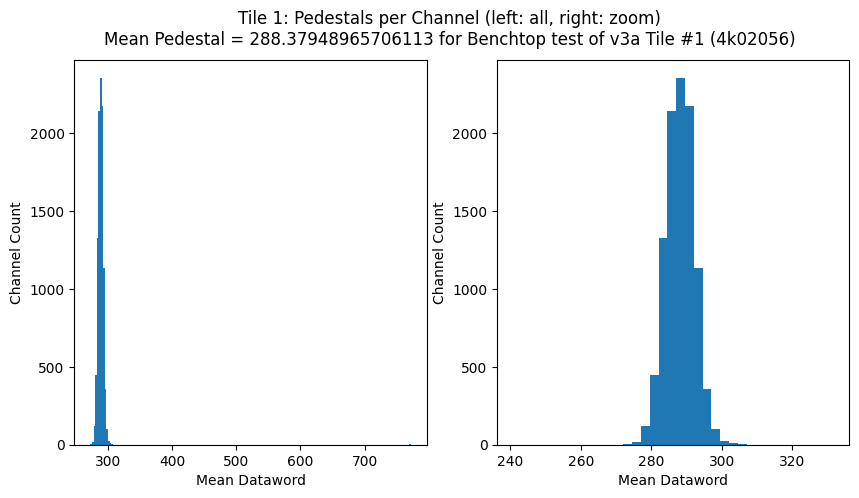

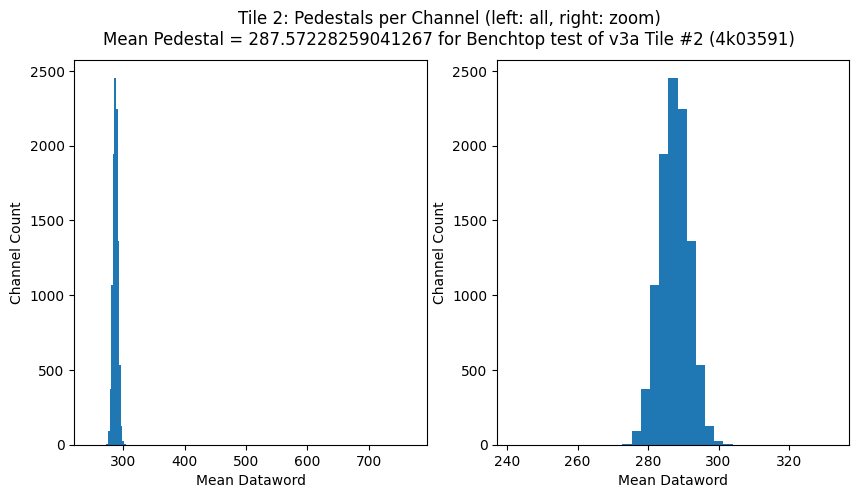

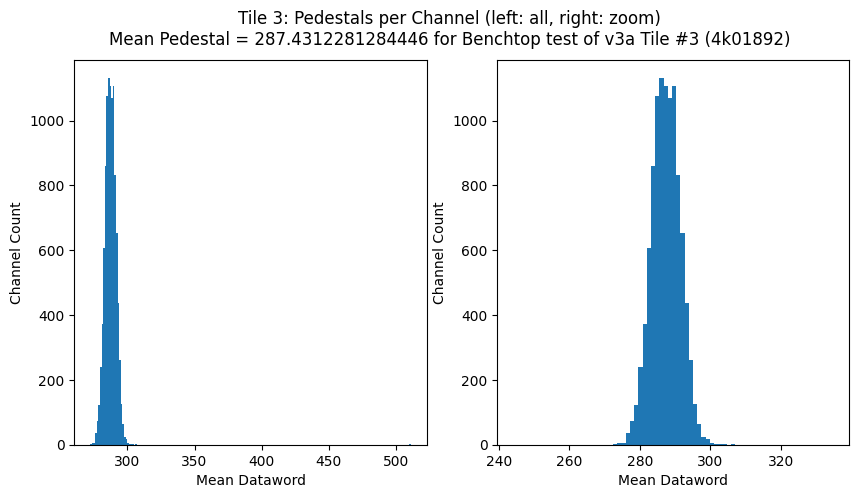

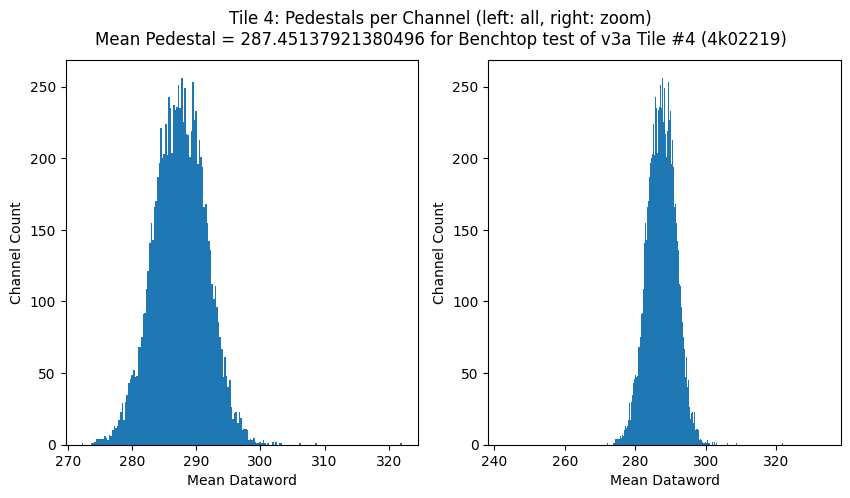

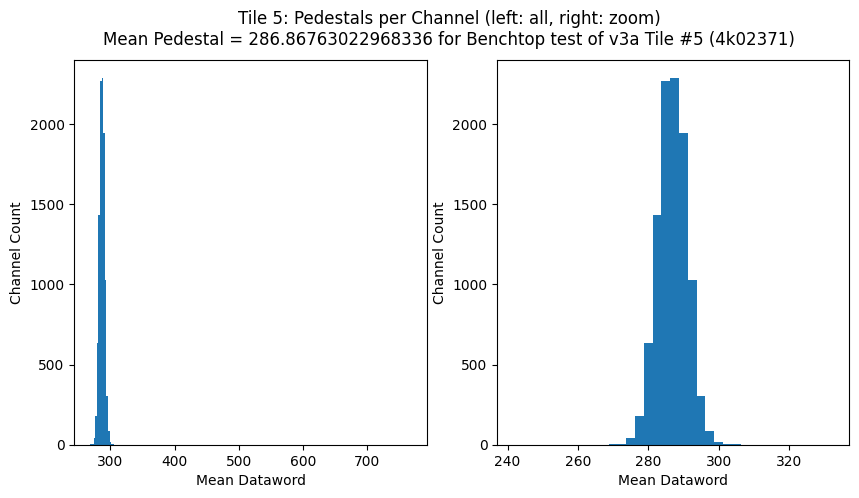

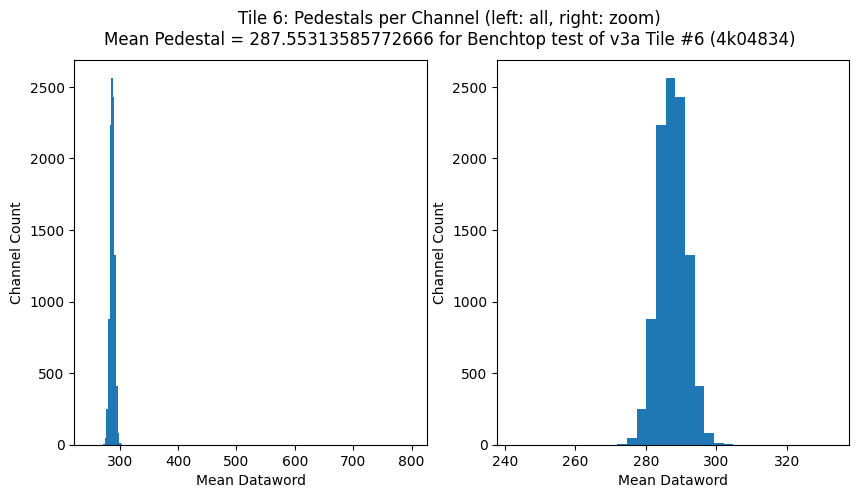

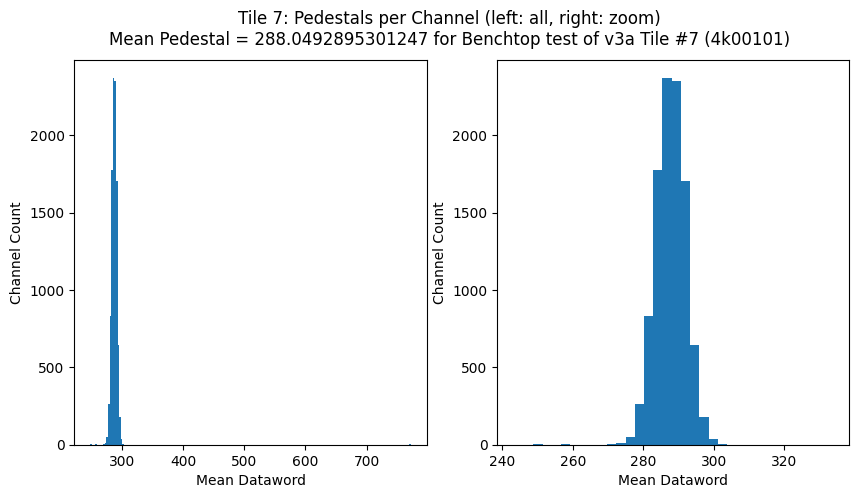

In [5]:
####################
# main
####################

print(f'Run Statistics for Data File {filename}:')

for tile in tiles:
    
    get_pedestals(filename, tile, chip_serial_number_list[tile], ig)
    
    write_ped_to_file(filename, tile, chip_serial_number_list[tile], pedestals)